In [2]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
import matplotlib.pyplot as plt
from Modeling.models.ROM import ROM
%matplotlib widget

In [3]:
w = np.geomspace(0.1, 800, 200)*2*np.pi
np.set_printoptions(precision=2, suppress=True)

print(f"w: {w}")

w: [   0.63    0.66    0.69    0.72    0.75    0.79    0.82    0.86    0.9
    0.94    0.99    1.03    1.08    1.13    1.18    1.24    1.29    1.35
    1.42    1.48    1.55    1.62    1.7     1.78    1.86    1.94    2.03
    2.13    2.23    2.33    2.44    2.55    2.67    2.79    2.92    3.05
    3.19    3.34    3.5     3.66    3.83    4.      4.19    4.38    4.58
    4.79    5.02    5.25    5.49    5.74    6.01    6.29    6.58    6.88
    7.2     7.53    7.88    8.24    8.63    9.02    9.44    9.88   10.33
   10.81   11.31   11.83   12.38   12.95   13.55   14.17   14.83   15.51
   16.23   16.98   17.77   18.59   19.44   20.34   21.28   22.27   23.29
   24.37   25.5    26.67   27.91   29.2    30.55   31.96   33.43   34.98
   36.59   38.28   40.05   41.9    43.84   45.86   47.98   50.2    52.52
   54.94   57.48   60.14   62.92   65.82   68.86   72.04   75.37   78.85
   82.5    86.31   90.3    94.47   98.83  103.4   108.17  113.17  118.4
  123.87  129.59  135.58  141.84  148.39  155.25  

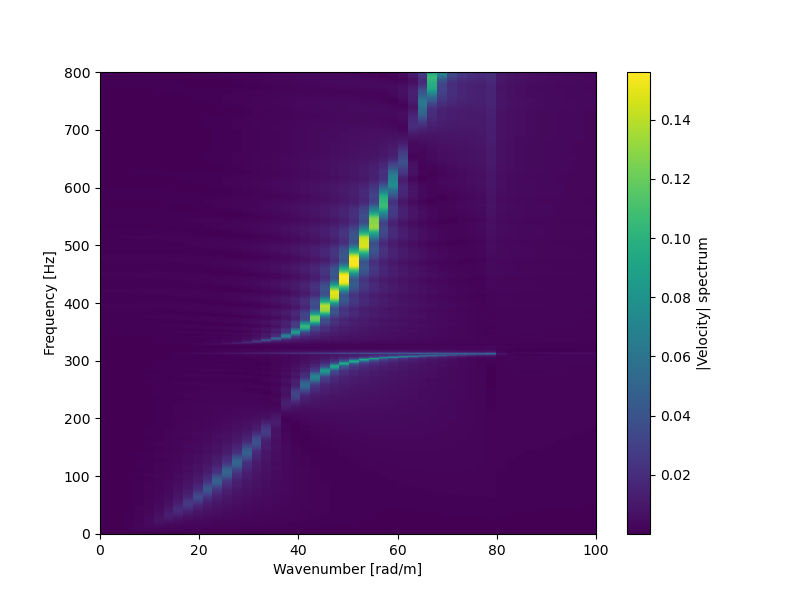

In [23]:
import matplotlib.pyplot as plt
Q = 300
params = PiezoBeamParams( 
    Q = Q, L_b=3.185
    )
rom = ROM(params, N=80)

# ki1 = 1000 + 1000 * (np.arange(rom.S//2) % 2)
# ki2 = 2000 - 1000 * (np.arange(rom.S//2) % 2)
x_eval = np.linspace(0, rom.p.L_b, 1000)
# K_i = np.concatenate([ki1, ki2])
K_i = 50; K_c = 0; R_c = 1e3
# w = np.concatenate([np.linspace(40, 50, 100), np.linspace(60, 70, 100)])*2*np.pi
w = np.linspace(0.1, 800, 1000)*2*np.pi
result = rom.dispersion_analysis(
j_exc=299, R_c=R_c, K_c=K_c, K_p=1e-4, K_i=K_i,
w=w, x_eval=x_eval
)
wavenumber = result['wavenumber']
freq = result['freq']
spectrum = result['spectrum']
velocity_field = result['veloc'] # shape (npts, nfreq)
plt.figure(figsize=(8,6))
plt.pcolormesh( wavenumber, freq, np.abs(spectrum), shading='auto')

plt.ylabel('Frequency [Hz]')
plt.xlabel('Wavenumber [rad/m]')
plt.xlim([0, 100])
plt.colorbar(label='|Velocity| spectrum')
 
# for i in range(0, len(freq),10):
#     plt.figure(figsize=(8,6))  
#     plt.plot(x_eval, velocity_field[:, i], label=f'Frequency = {freq[i]:.1f} Hz')
#     plt.legend()
#     plt.show()

C:\Users\nimae\AppData\Local\Temp\ipykernel_33584\1889850066.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


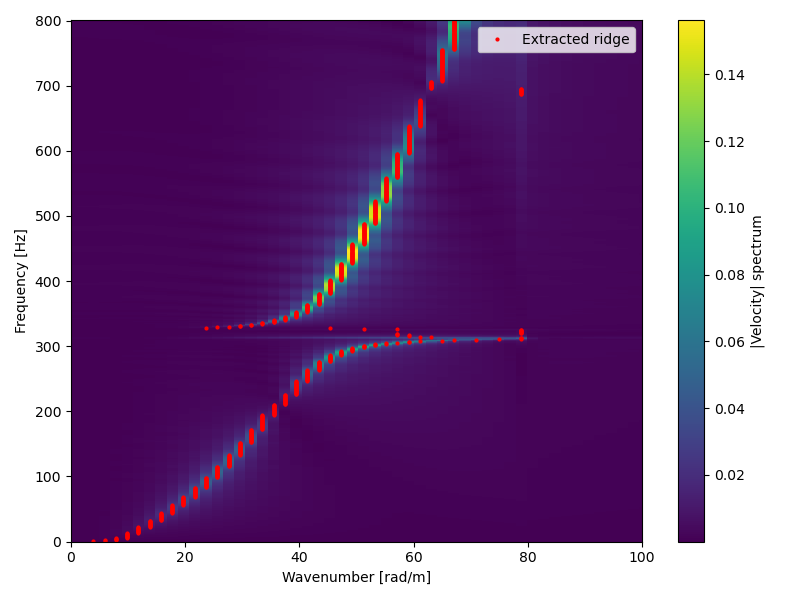

In [28]:

import numpy as np
import matplotlib.pyplot as plt

# dominant k index for each frequency
k_idx = np.argmax(np.abs(spectrum), axis=1)

# ridge
k_ridge = wavenumber[k_idx]
omega_ridge = 2 * np.pi * freq
plt.figure(figsize=(8,6))

# background spectrum
plt.pcolormesh(
	wavenumber,
	freq,
	np.abs(spectrum),
	shading='auto',
	cmap='viridis'
)

# ridge overlay
plt.plot(
	k_ridge,
	freq,
	'r.',
	ms=4,
	label='Extracted ridge'
)

plt.xlabel('Wavenumber [rad/m]')
plt.ylabel('Frequency [Hz]')
plt.xlim([0, 100])
plt.colorbar(label='|Velocity| spectrum')
plt.legend()
plt.tight_layout()
plt.show()


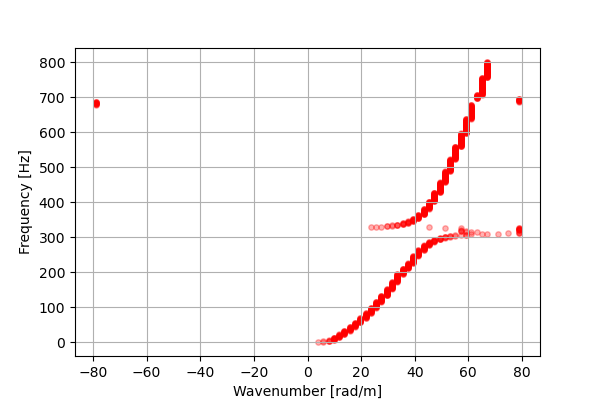

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path

fig, ax = plt.subplots(figsize=(6,4))

sc_all = ax.scatter(k_ridge, freq, c='r', s=15, alpha=0.3)
sc_sel = ax.scatter([], [], c='k', s=25)

ax.set_xlabel('Wavenumber [rad/m]')
ax.set_ylabel('Frequency [Hz]')
ax.grid(True)

pts = np.column_stack((k_ridge, freq))
selected = np.zeros(len(pts), dtype=bool)


def onselect(verts):
	path = Path(verts)
	mask = path.contains_points(pts)
	selected[:] = mask

	# update scatter data (THIS is the key fix)
	sc_all.set_offsets(pts[~selected])
	sc_sel.set_offsets(pts[selected])

	# plt.draw_idle()

lasso = LassoSelector(ax, onselect)
plt.show()


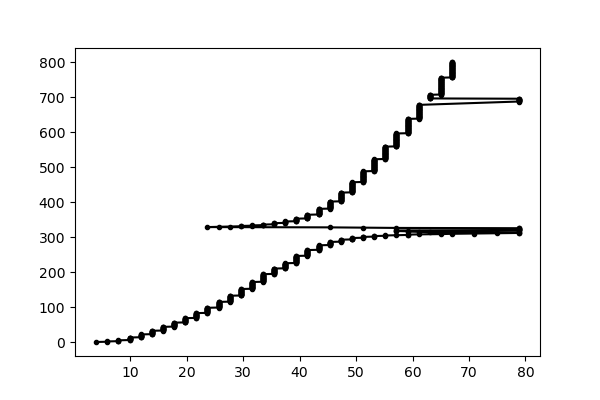

In [30]:
k_selected = k_ridge[selected]
f_selected = freq[selected]
plt.figure(figsize=(6,4))
plt.plot(k_selected, f_selected, 'k.-', label='filtered')

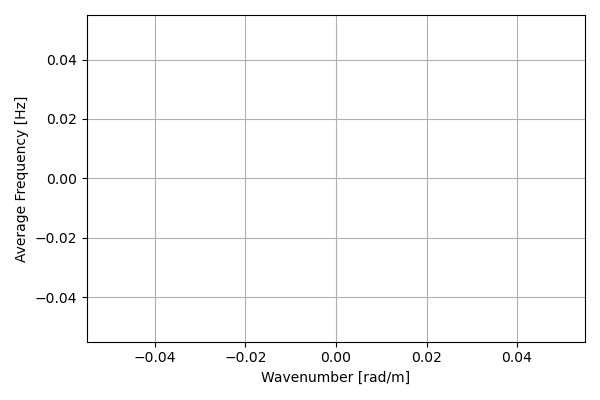

In [8]:
tol = 1e-3  # adjust if needed

k_sorted_idx = np.argsort(k_selected)
k_s = k_selected[k_sorted_idx]
f_s = f_selected[k_sorted_idx]

k_avg = []
f_avg = []

i = 0
while i < len(k_s):
	j = i + 1
	while j < len(k_s) and abs(k_s[j] - k_s[i]) < tol:
		j += 1

	k_avg.append(k_s[i:j].mean())
	f_avg.append(f_s[i:j].mean())
	i = j

k_avg = np.array(k_avg)
f_avg = np.array(f_avg)

plt.figure(figsize=(6,4))
plt.plot(k_avg, f_avg, 'ko-')
plt.xlabel('Wavenumber [rad/m]')
plt.ylabel('Average Frequency [Hz]')
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
from scipy.signal import savgol_filter

dk = np.mean(np.diff(k_avg))

omega = f_avg * 2*np.pi

# smooth + differentiate in one step
c_g = savgol_filter(
	omega,
	window_length=21,
	polyorder=3,
	deriv=1,
	delta=dk
)

# light post-smoothing
c_g = savgol_filter(c_g, 11, 2)

plt.figure()
plt.plot(k_avg, c_g)
plt.xlabel('k [rad/m]')
plt.ylabel('Group velocity [m/s]')
plt.grid(True)
plt.show()


c:\Users\nimae\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\nimae\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: array must not contain infs or NaNs

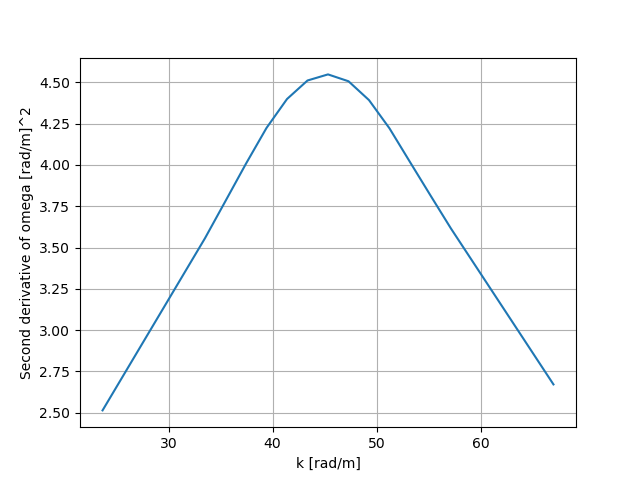

In [ ]:
# smooth + differentiate in one step
d2w_dk2 = savgol_filter(
	omega,
	window_length=21,
	polyorder=3,
	deriv=2,
	delta=dk
)

# light post-smoothing
d2w_dk2 = savgol_filter(d2w_dk2, 11, 2)

plt.figure()
plt.plot(k_avg, d2w_dk2)
plt.xlabel('k [rad/m]')
plt.ylabel('Second derivative of omega [rad/m]^2')
plt.grid(True)
plt.show()


In [ ]:

scales = rom.nondimensional_scales(K_i = K_i, K_c = K_c+0.001, R_c=R_c)
Omega = 2*np.pi* 254 * scales['t0']
q     = wavenumber * scales['x0']
# np.max(np.abs(z)) / scales['lambda0']
np.max(np.abs(w)) / scales['w0']

import numpy as np

def calculate_nlse_coefficients(rom, Omega, q, hardening=True):
    """
    Calculates NLSE coefficients P and Q.
    P relates to the curvature of the dispersion branch.
    Q relates to the shunt nonlinearity (based on Equation 50/Source 417).
    """
    # Define sgn_Lc: +1 for hardening, -1 for softening [cite: 108]
    sgn_Lc = 1 if hardening else -1
    
    # --- Calculate P (Dispersion Coefficient) ---
    # P = 0.5 * d^2_Omega / d_q^2 [cite: 389]
    # This is calculated by finding the curvature of your dispersion curve
    dq = 1e-4
    
    # Using your ROM's natural frequencies to estimate the branch curvature
    def get_Omega(k_val):
        # Placeholder for the dispersion relation Omega(q) [cite: 291]
        # In actual use, this pulls from the dispersion_analysis results
        return k_val**2 * np.sqrt(rom.p.YI / rom.p.m) 
        
    d2_Omega_dq2 = (get_Omega(q + dq) - 2*get_Omega(q) + get_Omega(q - dq)) / (dq**2)
    P = 0.5 * d2_Omega_dq2

    # --- Calculate Q (Nonlinearity Coefficient) ---
    # This is the Python implementation of 
    term1 = 1 / (-Omega**2 + q**4)
    term2 = 1 / (Omega**2)
    term3 = 1 / (-Omega**2 + 1)
    
    # The denominator accounts for coupling and resonance [cite: 417, 420]
    denominator = 2 * Omega * (-Omega**2 + 1) * (term1 + term2 + term3)
    Q = -3 * sgn_Lc / denominator

    # Stable solitons exist if PQ > 0 (Focusing Case) [cite: 426, 427]

    is_stable = (P * Q) > 0
    
    return {
        "P": P, 
        "Q": Q, 
        "is_stable": is_stable,
        "ratio": np.sqrt(abs(Q / (2 * P))) if is_stable else None
    }

# Evaluation Example: Acoustical branch (Point H) [cite: 402, 606]
# Requires hardening inductance (sgn_Lc = 1) [cite: 447]
params = calculate_nlse_coefficients(rom, Omega=0.09, q=0.8439, hardening=True)
print(f"NLSE Coefficients -> P: {params['P']:.4f}, Q: {params['Q']:.4f}, Stable: {params['is_stable']}")

t0 = scales['t0']
x0 = scales['x0']
delta = 0.5   # set δ̂ here
Omega = np.linspace(1e-4, 3.0, 5000)
q4 = (Omega**4 - Omega**2) / ((1 + delta**2)*Omega**2 - 1)
mask = q4 >= 0
Omega_p = Omega[mask]
q_p = q4[mask]**0.25
Omega_gap_low = (1 + delta**2)**(-0.5)
plt.figure(figsize=(6,4))
plt.plot(q_p/x0, Omega_p/t0/(2*np.pi), '.', lw=2)
plt.scatter(k_ridge, freq, c='r', s=15, alpha=0.3)
# plt.plot(q_p, Omega_p, '.', lw=2)
# band-gap markers
plt.axhline(1.0, ls='--', color='gray')
plt.axhline(Omega_gap_low, ls='--', color='gray')

plt.text(0.02, 1.02, r'$\Omega=1$', transform=plt.gca().transAxes)
plt.text(0.02, 0.35, r'$\Omega=(1+\delta^2)^{-1/2}$')

plt.xlabel(r'$q$')
plt.ylabel(r'$\Omega$')
plt.title('Dispersion relation and propagation bands')
plt.grid(True)
plt.tight_layout()
plt.show()

homogenized_paramters = rom.homogenized_parameters(R_c=R_c, K_c=-16e5, K_i=K_i)
Lc_bar = homogenized_paramters['Lc_bar']
q0 = 1          # example
idx0 = np.argmax(np.abs(q_p - q0))
dOmega_dq = np.gradient(Omega_p, q_p)
d2Omega_dq2 = np.gradient(dOmega_dq, q_p)
P = 0.5 * d2Omega_dq2[idx0]
Omega0 = Omega_p[idx0]
Q = (
    -3 * np.sign(Lc_bar)
    / (2 * Omega0)
    * (1 - Omega0**2)
    / ((1 - Omega0**2 + q0**4) * (Omega0**2 + 1 - Omega0**2 + 1))
)
if P*Q > 0:
    print("Focusing NLSE → envelope soliton exists")
else:
    print("Defocusing NLSE → no bright soliton")

def envelope_soliton(x, t, P, Q, phi0, eps, q0, w0, vg, ue=0.0):
    # slow variables
    # xi1  = eps * (x - vg*t)
    tau2 = eps**2 * t

    # envelope
    arg = eps * phi0 * np.sqrt(Q/(2*P)) *  (x - vg*t)
    A = (
        eps * phi0
        * 1/np.cosh(arg)
        * np.exp(1j*(q0*x - w0 *t))
        * np.exp(1/2*eps**2*Q*phi0**2*t)
    )

    # physical field
    w =  np.real(A )
    return w
# operating point
q0 = q_p[idx0]
Omega0 = Omega_p[idx0]

# dimensional
k0 = q0 
w0 = Omega0 

# group velocity
dOmega_dq = np.gradient(Omega_p, q_p)
vg = (dOmega_dq[idx0] / t0) * x0   # dω/dk
eps   = 0.05        # must be small
phi0  = 1.0         # envelope amplitude (O(1))
ue    = 0.0         # stationary soliton
x = np.linspace(0, 100.0, 2000)
t = 30

w = envelope_soliton(
    x, t,
    P=P, Q=Q,
    phi0=phi0,
    eps=eps,
    q0=q0,
    w0=w0,
    vg=vg
)

plt.figure(figsize=(7,3))
plt.plot(x, w, '-')
plt.xlabel("x [m]")
plt.ylabel("Displacement")
plt.title("Perturbation soliton solution (Eq. 51)")
plt.grid(True)
plt.tight_layout()
plt.show()


4718.30757320786

Focusing NLSE


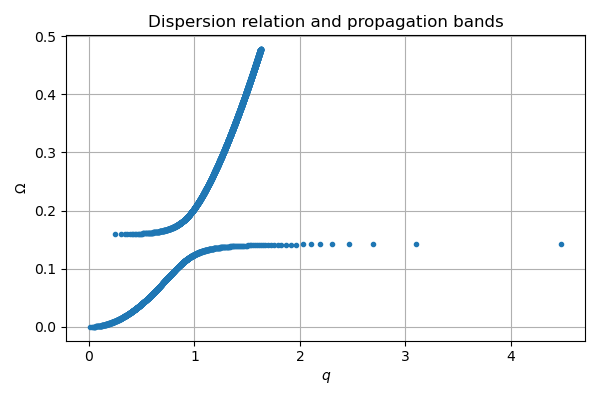

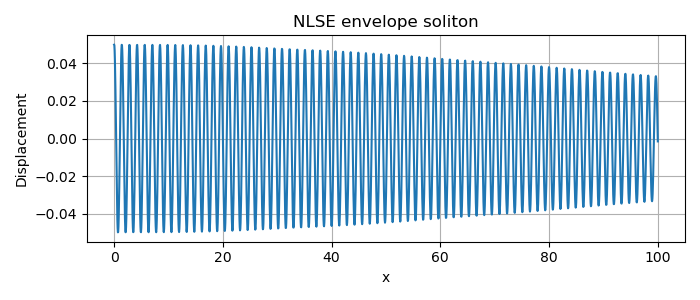

P = 0.006114372386692458  Q = 0.00046404361085638254


In [88]:
R_c = 1e3; K_c = -1e4
def compute_scales(rom, K_i, K_c, R_c):
    return rom.nondimensional_scales(K_i=K_i, K_c=K_c, R_c=R_c)
def dispersion_relation(Omega, delta):
    """
    Returns propagating branch q(Omega) for the homogenized lattice
    """
    q4 = (Omega**4 - Omega**2) / ((1 + delta**2)*Omega**2 - 1)
    mask = q4 >= 0
    return Omega[mask], q4[mask]**0.25

def dispersion_derivatives(Omega, q):
    dOmega_dq = np.gradient(Omega, q)
    d2Omega_dq2 = np.gradient(dOmega_dq, q)
    return dOmega_dq, d2Omega_dq2

def nlse_coefficients(Omega0, q0, d2Omega_dq2, Lc_bar):
    """
    Computes NLSE coefficients P and Q at (q0, Omega0)
    """
    P = 0.5 * d2Omega_dq2

    Q = (
        -3 * np.sign(Lc_bar)
        / (2 * Omega0)
        * (1 - Omega0**2)
        / ((1 - Omega0**2 + q0**4) * (Omega0**2 + 1))
    )

    return P, Q, (P * Q > 0)

def envelope_soliton(x, t, P, Q, phi0, eps, q0, Omega0, vg):
    arg = eps * phi0 * np.sqrt(Q / (2 * P)) * (x - vg * t)

    A = (
        eps * phi0
        / np.cosh(arg)
        * np.exp(1j * (q0 * x - Omega0 * t))
        * np.exp(0.5 * eps**2 * Q * phi0**2 * t)
    )

    return np.real(A)

def plot_dispersion(q, Omega, x0, t0, k_ridge=None, freq=None):
    plt.figure(figsize=(6, 4))
    plt.plot(q, Omega/(2*np.pi), '.', lw=2)

    if k_ridge is not None:
        plt.scatter(k_ridge, freq, c='r', s=15, alpha=0.3)

    plt.xlabel(r'$q$')
    plt.ylabel(r'$\Omega$')
    plt.title('Dispersion relation and propagation bands')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_soliton(x, w):
    plt.figure(figsize=(7, 3))
    plt.plot(x, w)
    plt.xlabel("x")
    plt.ylabel("Displacement")
    plt.title("NLSE envelope soliton")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Parameters ---
delta = 0.5
q_target = 1.0
eps = 0.05
phi0 = 1.0
t = 30

# --- Scales ---
scales = compute_scales(rom, K_i, K_c+0.001, R_c)
t0, x0 = scales['t0'], scales['x0']

# --- Dispersion ---
Omega = np.linspace(1e-4, 3.0, 5000)
Omega_p, q_p = dispersion_relation(Omega, delta)

# --- Operating point ---
idx0 = np.argmax(np.abs(q_p - q_target))
Omega0, q0 = Omega_p[idx0], q_p[idx0]

# --- Derivatives ---
dOmega_dq, d2Omega_dq2 = dispersion_derivatives(Omega_p, q_p)

# --- Homogenized parameters ---
params = rom.homogenized_parameters(R_c=R_c, K_c=K_c, K_i=K_i)
Lc_bar = params['Lc_bar']

# --- NLSE coefficients ---
P, Q, focusing = nlse_coefficients(
    Omega0, q0, d2Omega_dq2[idx0], Lc_bar
)

print("Focusing NLSE" if focusing else "Defocusing NLSE")

# --- Group velocity ---
vg = (dOmega_dq[idx0] / t0) * x0

# --- Soliton ---
x = np.linspace(0, 100.0, 2000)
w = envelope_soliton(x, t=0.1, P=P, Q=Q, phi0=phi0, eps=eps, q0=q0, Omega0=Omega0, vg=vg)

# --- Plots ---
plot_dispersion(q_p, Omega_p, x0, t0)
plot_soliton(x, w)
print("P =", P, " Q =", Q)

In [66]:
Omega0
# q0
x0
1/t0


2056.723581469586